In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import csv
import pandas as pd
import tensorly as tl
import os
from tqdm import tqdm
import seaborn as sns

In [3]:
DATA_DIR  = Path('/home/isacco/DATA/ZOU_GPR')
CASES_DIR = DATA_DIR / 'Datasets_Isacco'

COLS = [
    'x','y','z','alphat',
    'C2H','C2H2','C2H3','C2H4','C2H5','C2H6','C3H7','C3H8',
    'CH','CH2','CH2CHO','CH2CO','CH2O','CH2OH','CH2S','CH3','CH3CHO','CH3O','CH3OH',
    'CH4','CO','CO2','epsilon','H','H2','H2O','H2O2','HCCO','HCCOH','HCO','HO2',
    'k','N2','O2','OH','p','T','Ux','Uy','Uz'
]
COLS_IDX = {name: i for i, name in enumerate(COLS)}
NAMES = {i: name for i, name in enumerate(COLS)}
IMPORTANT_FIELDS = ['T','OH','CO2', 'CH4', 'H2O', 'CO']

RELEVANT_COLS_IDXS = np.array(
    [COLS_IDX[name] for name in IMPORTANT_FIELDS]
)
data  = pd.read_csv(DATA_DIR / 'case_summary.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   case_id    25 non-null     int64  
 1   case_name  25 non-null     object 
 2   Re         25 non-null     int64  
 3   Y_CH4      25 non-null     float64
 4   Y_H2       25 non-null     float64
 5   Y_N2       25 non-null     float64
 6   X_CH4      25 non-null     float64
 7   X_H2       25 non-null     float64
 8   X_N2       25 non-null     float64
 9   U_fuel     25 non-null     float64
 10  rho        25 non-null     float64
 11  mu_mix     25 non-null     float64
 12  W_mix      25 non-null     float64
 13  Tin(K)     25 non-null     int64  
dtypes: float64(10), int64(3), object(1)
memory usage: 2.9+ KB


In [4]:
print(os.listdir(CASES_DIR))

['Case18_mfH2_0.16_Re_15000.xy', 'Case11_mfH2_0.12_Re_11000.xy', 'Case20_mfH2_0.16_Re_19000.xy', 'Case09_mfH2_0.08_Re_17000.xy', 'Case14_mfH2_0.12_Re_17000.xy', 'Case01_mfH2_0.04_Re_11000.xy', 'Case05_mfH2_0.04_Re_19000.xy', 'Case24_mfH2_0.20_Re_17000.xy', 'Case21_mfH2_0.20_Re_11000.xy', 'Case03_mfH2_0.04_Re_15000.xy', 'Case23_mfH2_0.20_Re_15000.xy', 'Case06_mfH2_0.08_Re_11000.xy', 'Case25_mfH2_0.20_Re_19000.xy', 'Case17_mfH2_0.16_Re_13000.xy', 'Case19_mfH2_0.16_Re_17000.xy', 'Case02_mfH2_0.04_Re_13000.xy', 'Case15_mfH2_0.12_Re_19000.xy', 'Case04_mfH2_0.04_Re_17000.xy', 'Case16_mfH2_0.16_Re_11000.xy', 'Case08_mfH2_0.08_Re_15000.xy', 'Case12_mfH2_0.12_Re_13000.xy', 'Case07_mfH2_0.08_Re_13000.xy', 'Case13_mfH2_0.12_Re_15000.xy', 'Case10_mfH2_0.08_Re_19000.xy', 'Case22_mfH2_0.20_Re_13000.xy']


In [5]:
# Load case_summary.csv without pandas
with open(DATA_DIR / 'case_summary.csv') as f:
    reader = csv.DictReader(f)
    summary_rows = list(reader)

summary_keys = list(summary_rows[0].keys())
summary = {k: np.array([float(r[k]) if k != 'case_name' else r[k] for r in summary_rows])
           for k in summary_keys if k not in ('case_name',)}
summary['case_name'] = np.array([r['case_name'] for r in summary_rows])

print('Cases loaded:', len(summary_rows))
print('Re range:', summary['Re'].min(), '–', summary['Re'].max())
print('Y_H2 range:', summary['Y_H2'].min(), '–', summary['Y_H2'].max())

Cases loaded: 25
Re range: 11000.0 – 19000.0
Y_H2 range: 0.04 – 0.2


In [6]:
def load_case(path):
    """Return (grid, x_vals, z_vals) with grid shape (Nz, Nx, 44)."""
    raw = np.loadtxt(path, skiprows=1)
    x_vals = np.unique(raw[:, COLS_IDX['x']])
    z_vals = np.unique(raw[:, COLS_IDX['z']])
    idx = np.lexsort((raw[:, COLS_IDX['x']], raw[:, COLS_IDX['z']]))
    grid = raw[idx].reshape(len(z_vals), len(x_vals), len(COLS))
    return grid#, x_vals, z_vals

case_path = sorted(CASES_DIR.glob('*.xy'))[0]
print('Loading:', case_path.name)
grid = load_case(case_path)
print(f'Grid shape: {grid.shape}')

Loading: Case01_mfH2_0.04_Re_11000.xy
Grid shape: (101, 84, 44)


In [7]:
print(len(RELEVANT_COLS_IDXS))

6


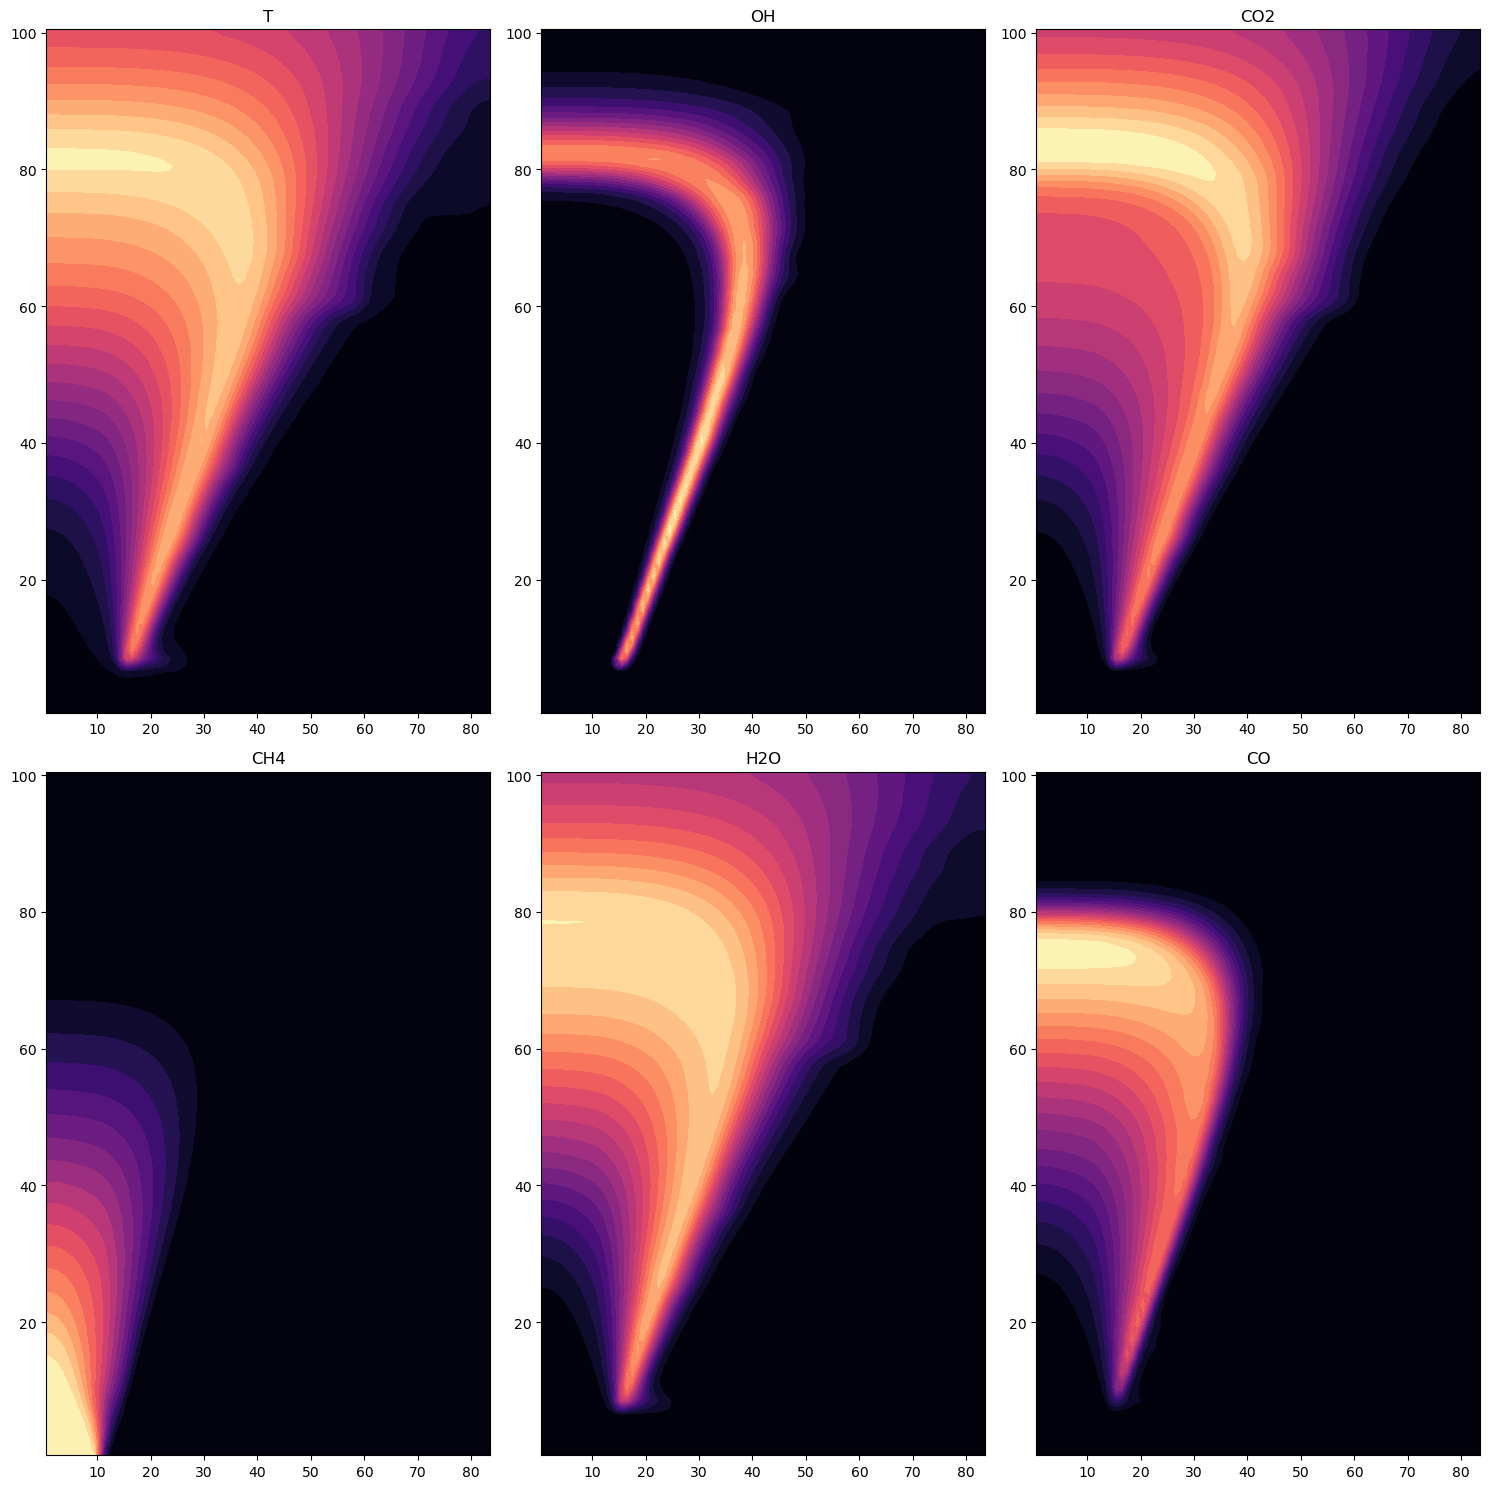

In [8]:
n_cols = 3
n_rows = (len(RELEVANT_COLS_IDXS) + n_cols - 1) // n_cols

n_plots = len(RELEVANT_COLS_IDXS)
fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 15))

axs = axs.flatten()

for i, idx in enumerate(RELEVANT_COLS_IDXS):
    axs[i].contourf(
        grid[:, :, idx],
        origin='lower',
        levels=20,
        cmap='magma'
    )
    axs[i].set_title(NAMES[idx])

# Hide unused subplots
for j in range(n_plots, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()


In [9]:
import os
a = np.array([load_case(os.path.join(CASES_DIR,p)) for p in  os.listdir(CASES_DIR) if p.endswith('.xy')])
print(a.shape)

(25, 101, 84, 44)


In [10]:
re_vals = [11000, 13000, 15000, 17000, 19000]
mf_vals = [0.04, 0.08, 0.12, 0.16, 0.20]

_g = load_case(sorted(CASES_DIR.glob('*.xy'))[0])
Nz, Nx, Nspec = _g.shape  # 101, 84, 44

tensor = np.empty((len(re_vals), len(mf_vals), Nz, Nx, Nspec), dtype=np.float32)

for i_re, re in enumerate(re_vals):
    for i_mf, mf in enumerate(mf_vals):
        matches = list(CASES_DIR.glob(f'*_mfH2_{mf:.2f}_Re_{re}.xy'))
        assert len(matches) == 1, f"Expected 1 file, got {len(matches)} for Re={re}, mfH2={mf}"
        tensor[i_re, i_mf] = load_case(matches[0])

print(f"Tensor shape: {tensor.shape}")
print(f"Re axis:   {re_vals}")
print(f"mfH2 axis: {mf_vals}")

#Faccio standard scale
species_mean = tensor.mean(axis=(0,1,2,3), keepdims=True)
species_std  = tensor.std(axis=(0,1,2,3), keepdims=True)

tensor_scaled = (tensor - species_mean) / species_std

Tensor shape: (5, 5, 101, 84, 44)
Re axis:   [11000, 13000, 15000, 17000, 19000]
mfH2 axis: [0.04, 0.08, 0.12, 0.16, 0.2]


/tmp/ipykernel_34867/4075623926.py:23: RuntimeWarning: invalid value encountered in divide
  tensor_scaled = (tensor - species_mean) / species_std


In [11]:
def select_rank_by_ratio(array, varepsilon):
    sigma_1 = array[0]
    for r, value in enumerate(array):
        if value / sigma_1 <= varepsilon:
            return r
    return len(array)

def select_rank_by_energy(array, varepsilon):
    total_energy = np.sum(array)
    cumulative_energy = np.cumsum(array)
    num_components = np.sum(cumulative_energy <= varepsilon * total_energy) + 1
    return min(num_components, len(array))

In [12]:
eps = 1e-12

species_mean = tensor.mean(axis=(0,1,2,3), keepdims=True)
species_std  = tensor.std(axis=(0,1,2,3), keepdims=True)

species_std_safe = np.where(species_std < eps, 1.0, species_std)

tensor_scaled = (tensor - species_mean) / species_std_safe

assert np.all(np.isfinite(tensor_scaled))

trunc_idxs = []
factors = []
singular_values = []

for mode in tqdm(range(tensor_scaled.ndim)):

    unfolded = tl.unfold(tensor_scaled, mode)

    U, S, Vh = np.linalg.svd(unfolded, full_matrices=False)

    trunc_idx = select_rank_by_energy(S, 0.99)

    trunc_idxs.append(trunc_idx)

    factors.append(U[:, :trunc_idx])

    singular_values.append(S)

core = tl.tenalg.multi_mode_dot(
    tensor_scaled,
    [f.T for f in factors],
    modes=[0,1,2,3,4]
)

U_re, U_mf, U_z, U_x, U_spec = factors

100%|██████████| 5/5 [00:03<00:00,  1.49it/s]


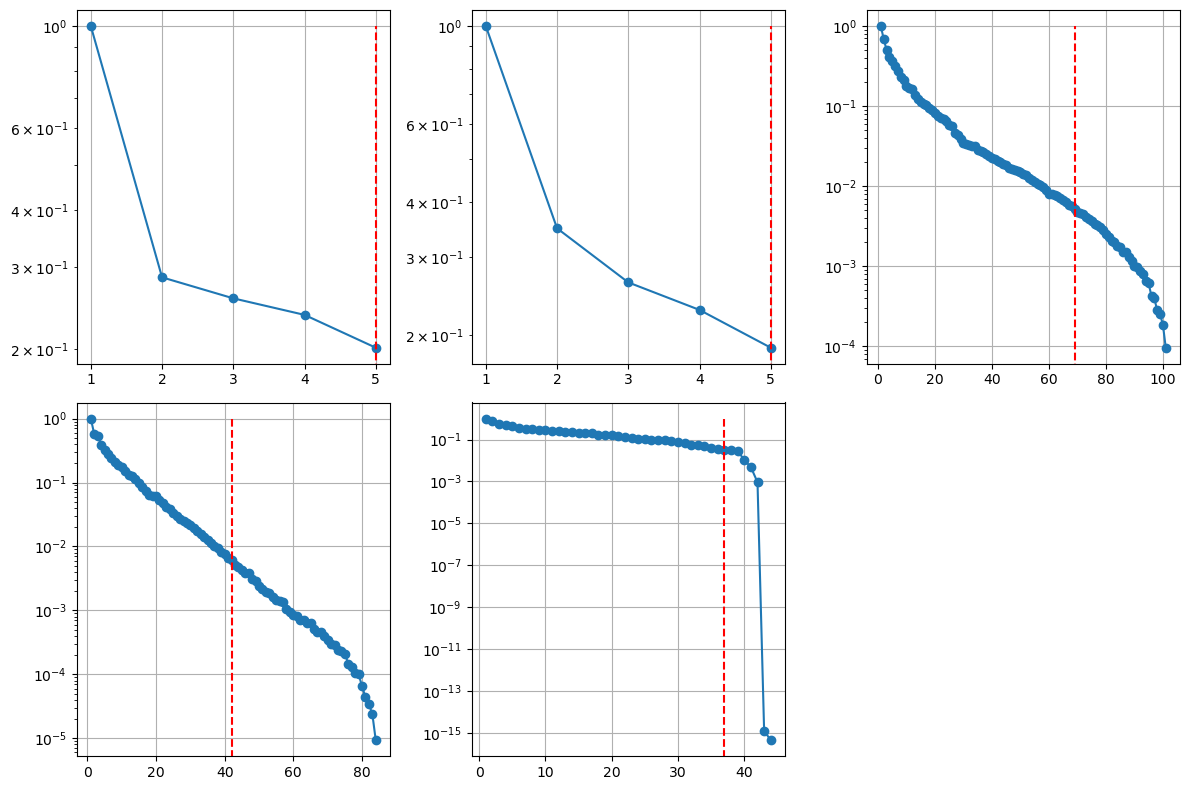

In [13]:
n_cols = 3
n_rows = (len(singular_values) + n_cols - 1) // n_cols

n_plots = len(singular_values)
fig, axs = plt.subplots(n_rows, n_cols, figsize=(12, 8))

axs = axs.flatten()

for i, sv in enumerate(singular_values):
    a = axs[i]
    a.plot([i for i in range(1, len(sv)+1)], sv/sv[0], 'o-')
    #axs[i].set_xscale('log')
    a.vlines(x=trunc_idxs[i], ymin=0, ymax=1, color='red', linestyle='--', label=f'trunc_idx={trunc_idxs[i]}')
    a.set_yscale('log')
    a.grid()

for j in range(n_plots, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

re_vals = np.array([11000, 13000, 15000, 17000, 19000])
mf_vals = np.array([0.04, 0.08, 0.12, 0.16, 0.20])

kernel = (
    ConstantKernel(1.0) *
    Matern(length_scale=5000.0, nu=2.5)
    + WhiteKernel(1e-6)
)
gpr_hosvd = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, normalize_y=True)
gpr_hosvd.fit(re_vals.reshape(-1, 1), U_re)

# Re=13000 is now a training point — pick a new out-of-sample target
X = np.array([14000]).reshape(-1, 1)

alpha_mean, alpha_std = gpr_hosvd.predict(X, return_std=True)
alpha_mean = alpha_mean.squeeze()
alpha_std = alpha_std.squeeze()

ValueError: Found input variables with inconsistent numbers of samples: [4, 5]

In [16]:
U_re_new = np.vstack([U_re, alpha_mean])
reconstructed = tl.tenalg.multi_mode_dot(core, [U_re_new, U_mf, U_z, U_x, U_spec], modes=[0,1,2,3,4]) 


[11000 15000 17000 19000]
[[-0.41789103  0.65977579  0.28282008  0.55684453]
 [-0.50847471  0.39070058 -0.2091559  -0.73828202]
 [-0.52754813 -0.35401046 -0.67877233  0.36829019]
 [-0.53713459 -0.53546762  0.64461982 -0.09605298]
 [-0.49776214  0.04024956  0.00987792  0.02269993]]


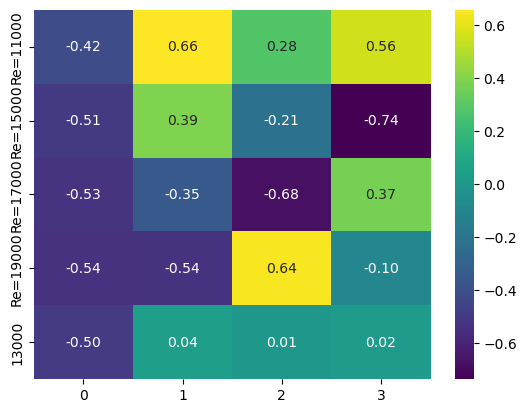

<Figure size 640x480 with 0 Axes>

In [118]:
sns.heatmap(U_re_new, annot=True, fmt=".2f", cmap='viridis', yticklabels=[f'Re={r}' for r in re_vals] + [13000])
plt.figure()
print(re_vals)
print(U_re_new)

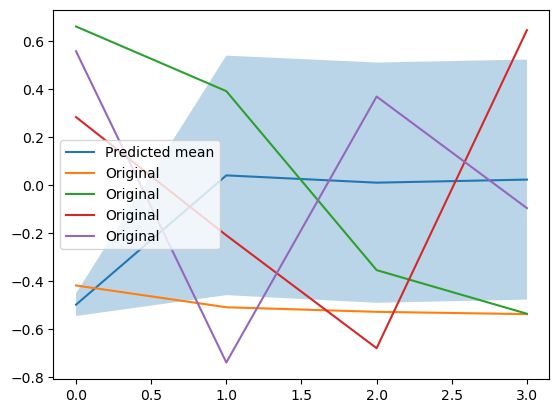

In [112]:
x = np.arange(len(alpha_mean))

plt.plot(x, alpha_mean, label='Predicted mean')
plt.plot(x, U_re, label='Original')

plt.fill_between(
    x,
    alpha_mean - alpha_std,
    alpha_mean + alpha_std,
    alpha=0.3,
)

plt.legend()
plt.show()

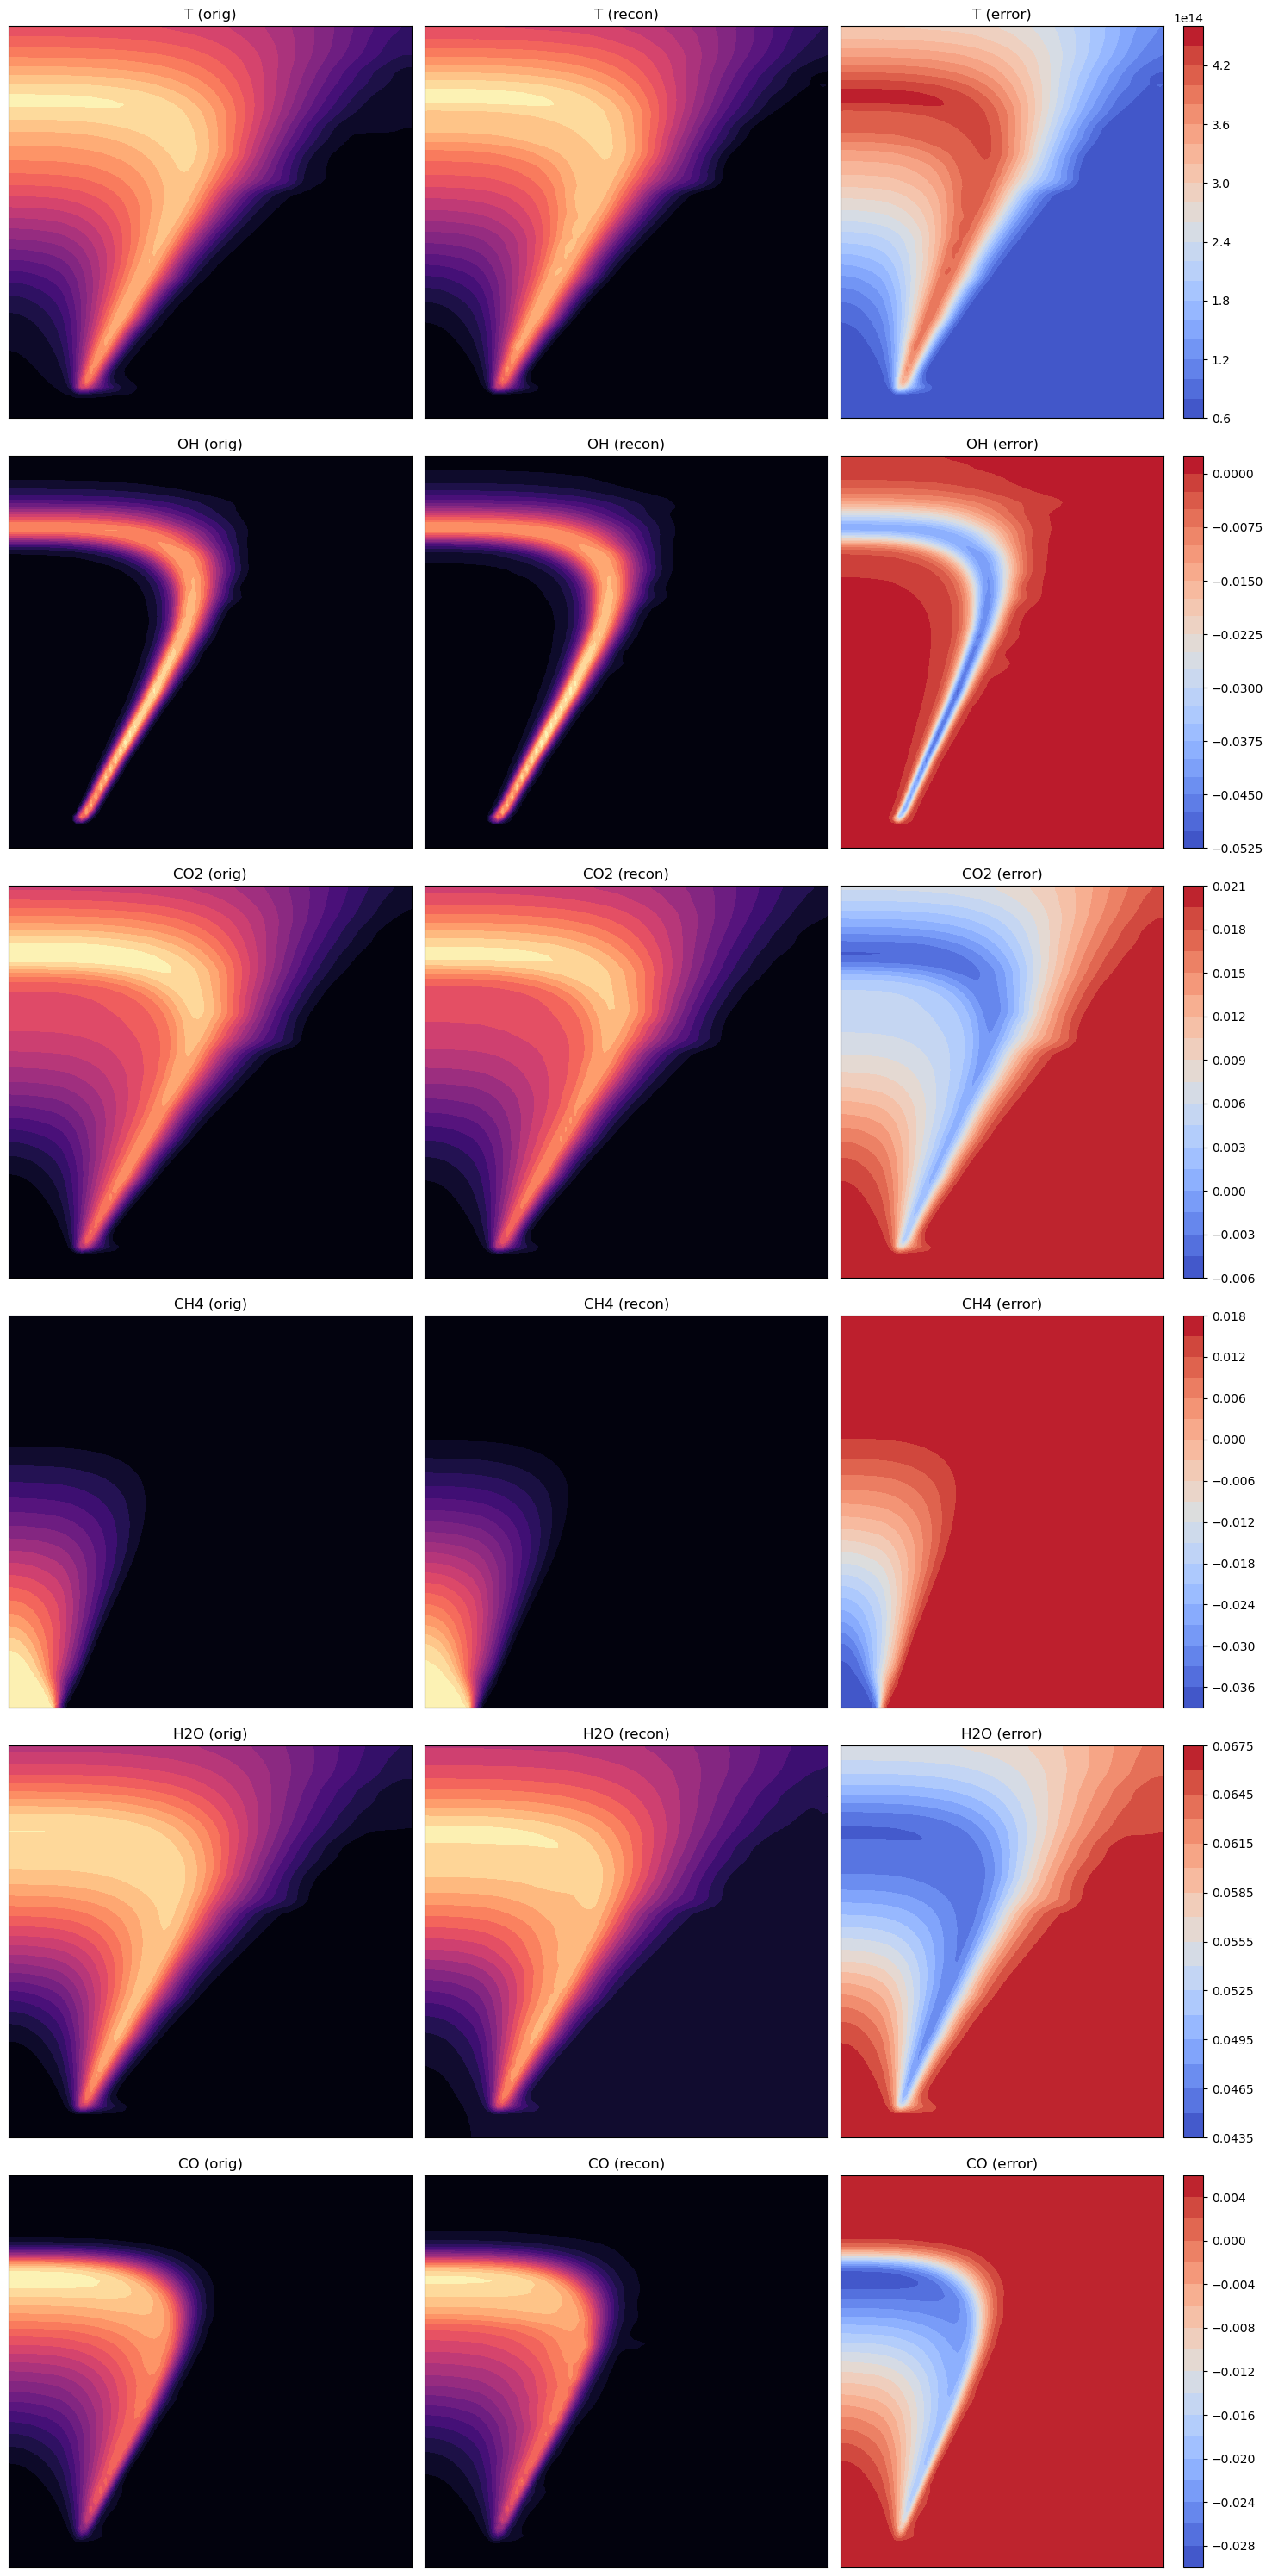

In [ ]:
n_cols = 3
n_rows = len(RELEVANT_COLS_IDXS)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
reconstructed = reconstructed * species_std + species_mean
for i, idx in enumerate(RELEVANT_COLS_IDXS):

    orig = grid[:, :, idx]
    recon = reconstructed[0, 0, :, :, idx]
    err = recon - orig / np.linalg.norm(orig)   # or np.abs(recon - orig)

    # Original
    im0 = axs[i, 0].contourf(orig, origin='lower', levels=20, cmap='magma')
    axs[i, 0].set_title(f"{NAMES[idx]} (orig)")

    # Reconstructed
    im1 = axs[i, 1].contourf(recon, origin='lower', levels=20, cmap='magma')
    axs[i, 1].set_title(f"{NAMES[idx]} (recon)")

    # Error
    im2 = axs[i, 2].contourf(err, origin='lower', levels=20, cmap='coolwarm')
    axs[i, 2].set_title(f"{NAMES[idx]} (error)")
    plt.colorbar(im2, ax=axs[i, 2])

# Optional: turn off axis ticks for cleaner look
for ax in axs.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()